<a href="https://colab.research.google.com/github/Abinesh0916/Movie-Industry-Data-Analysis-using-Python/blob/main/Movie_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files
file = files.upload()

In [12]:
import pandas as pd
df = pd.read_csv("movies.csv")
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [14]:
df.dtypes

,0
name,object
rating,object
genre,object
year,int64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [15]:
df.isna().sum()

,0
name,0
rating,77
genre,0
year,0
released,2
score,3
votes,3
director,0
writer,3
star,1


In [16]:
rating_dict={
    "G":"General Audiences",
    "PG":"Parental Guidance",
    "PG-13":"Parents Strongly Cautioned",
    "R":"Restricted",
    "NC-17":"Adults Only",
    "Nan":"None"
}
df["rating"].replace(rating_dict,inplace=True)

/tmp/ipykernel_1115/3386240743.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].replace(rating_dict,inplace=True)


In [17]:
df["votes"]= pd.to_numeric(df["votes"],errors = "coerce").astype("Int64")
df['budget'] = pd.to_numeric(df["budget"],errors ="coerce" ).astype("Int64")
df['gross'] = pd.to_numeric(df["gross"],errors ="coerce" ).astype("Int64")
df['gross'] = pd.to_numeric(df["gross"],errors ="coerce" ).astype("Int64")



In [18]:
df["country_released"] = df["released"].str.extract(r'\((.*?)\)')
df["released"] = df["released"].str.replace(r'\(.*?\)', " ", regex=True).str.strip()
df["released"] = pd.to_datetime(df["released"], dayfirst=True, errors="coerce")
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,country_released
0,The Shining,Restricted,Drama,1980,1980-06-13,8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,United States
1,The Blue Lagoon,Restricted,Adventure,1980,1980-07-02,5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,United States
2,Star Wars: Episode V - The Empire Strikes Back,Parental Guidance,Action,1980,1980-06-20,8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,United States
3,Airplane!,Parental Guidance,Comedy,1980,1980-07-02,7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,United States
4,Caddyshack,Restricted,Comedy,1980,1980-07-25,7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,2020-10-23,3.1,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,<NA>,NaN,90.0,United States
7664,Dream Round,NaN,Comedy,2020,2020-02-07,4.7,36,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,<NA>,<NA>,Cactus Blue Entertainment,90.0,United States
7665,Saving Mbango,NaN,Drama,2020,2020-04-27,5.7,29,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750,<NA>,Embi Productions,NaN,Cameroon
7666,It's Just Us,NaN,Drama,2020,2020-10-01,NaN,<NA>,James Randall,James Randall,Christina Roz,United States,15000,<NA>,NaN,120.0,United States


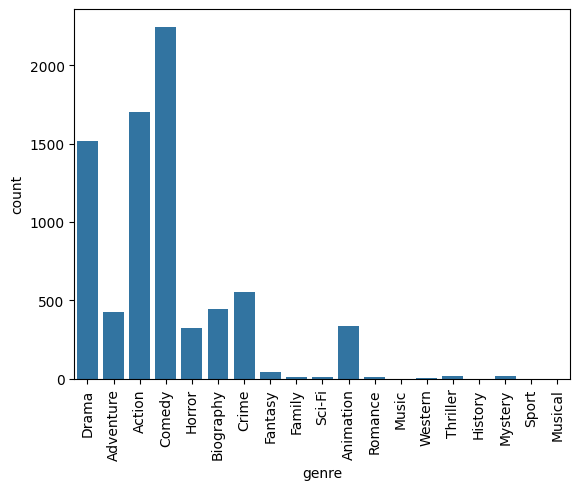

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x= "genre",data = df)
plt.xticks(rotation = 90)
plt.show()

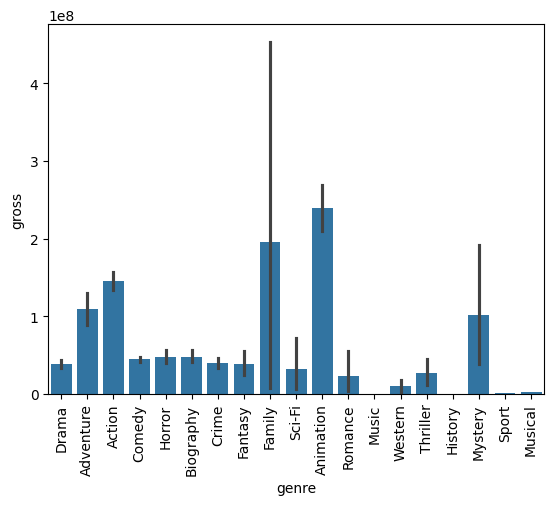

In [20]:
sns.barplot(x="genre",y="gross",data=df)
plt.xticks(rotation=90)
plt.show()

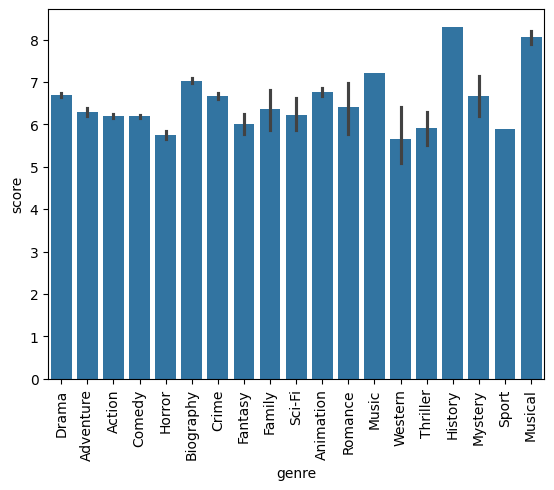

In [21]:
sns.barplot(x="genre",y="score",data=df)
plt.xticks(rotation=90)
plt.show()

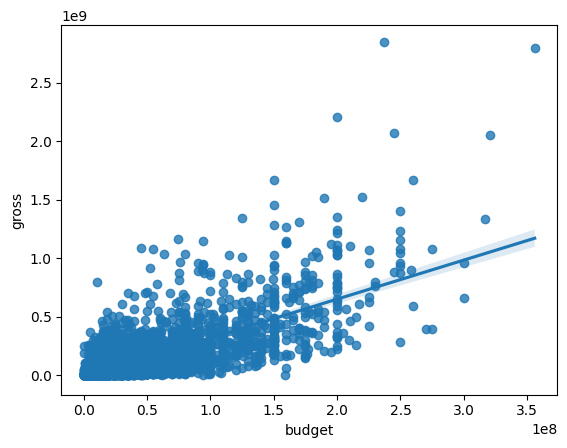

In [22]:
sns.regplot(x="budget", y= "gross",data=df)
plt.show()

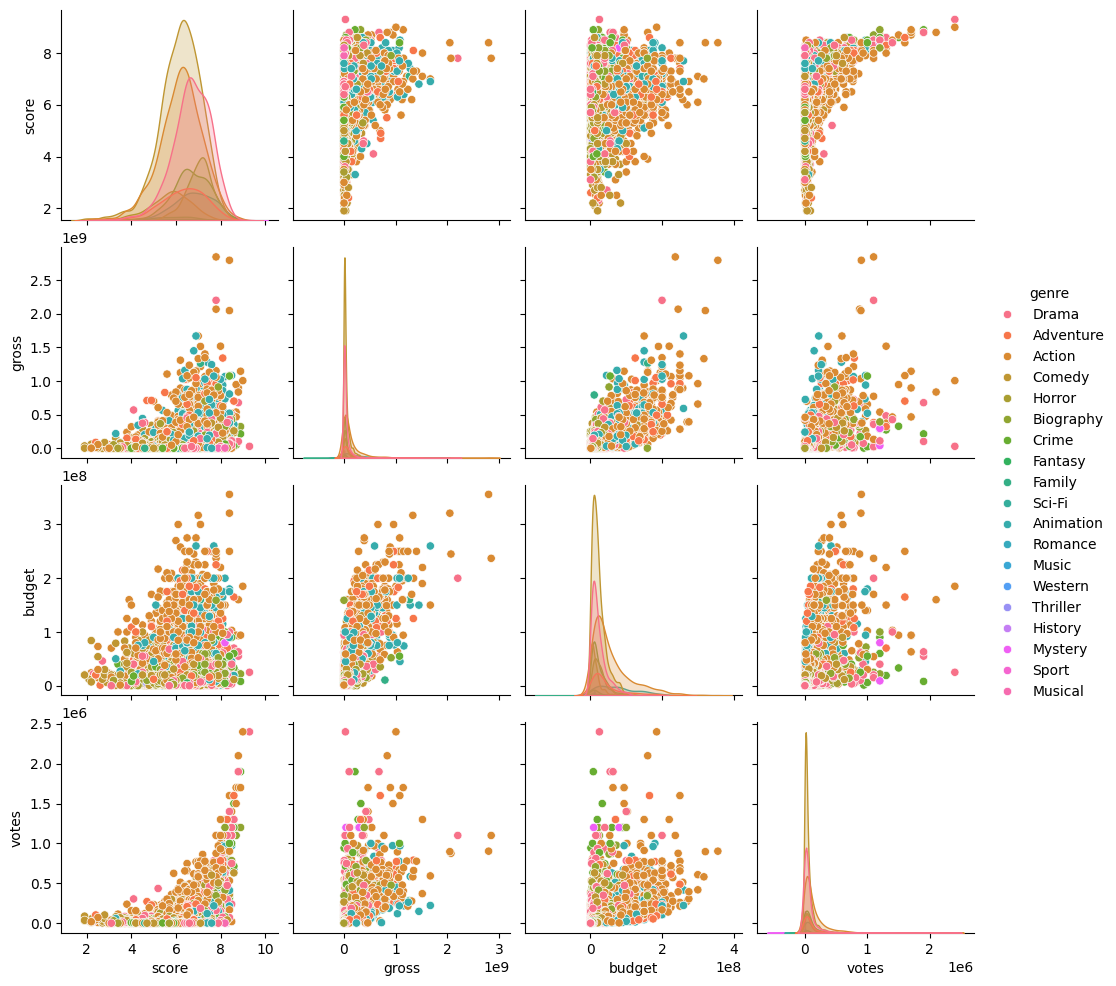

In [32]:
sns.pairplot(df, vars=["score","gross","budget","votes"], hue ="genre")
plt.show()

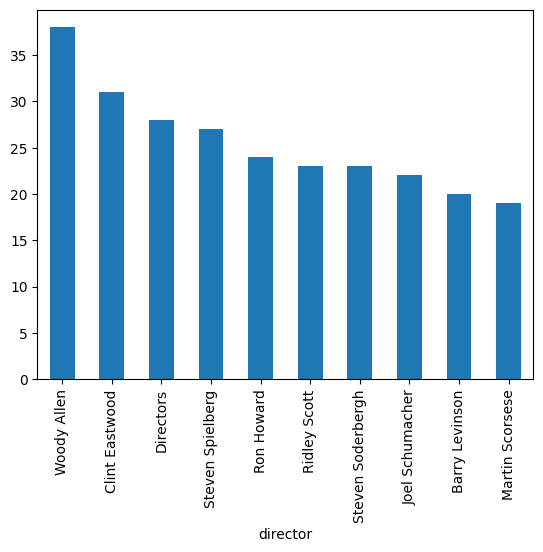

In [24]:
top_director = df["director"].value_counts().head(10)
top_director.plot(kind="bar")
plt.xlabel=("Director")
plt.ylabel=("Number of Movies")
plt.title=("Top 10 Directors ")
plt.show()

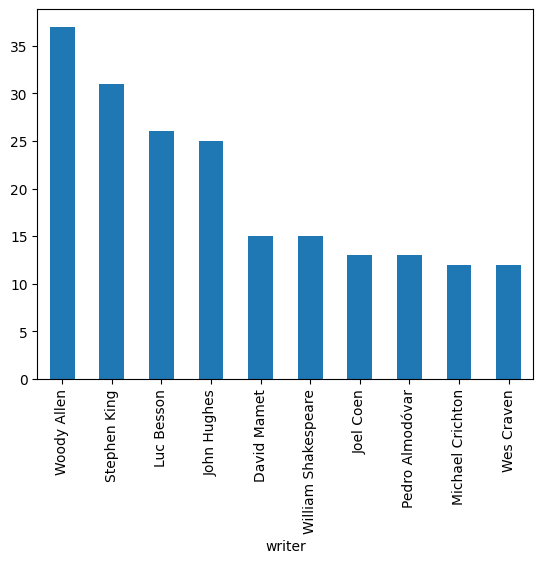

In [25]:
top_writer = df["writer"].value_counts().head(10)
top_writer.plot(kind="bar")
plt.xlabel=("writer")
plt.ylabel=("Number of Movies")
plt.title=("Top 10 writer ")
plt.show()

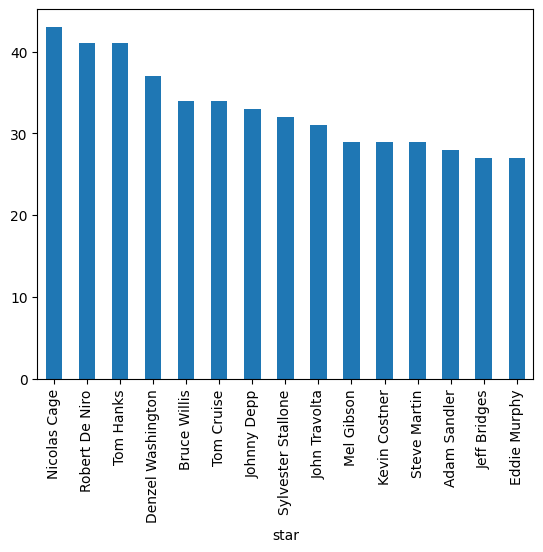

In [26]:
top_star = df["star"].value_counts().head(15)
top_star.plot(kind="bar")
plt.xlabel=("star")
plt.ylabel=("Number of Movies")
plt.title=("Top 15 star ")
plt.show()

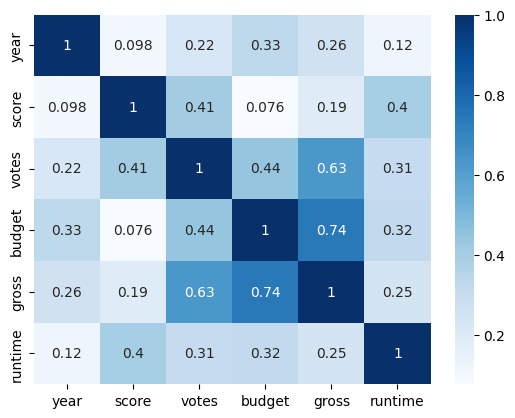

In [27]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")
plt.show()

<Axes: xlabel='year'>

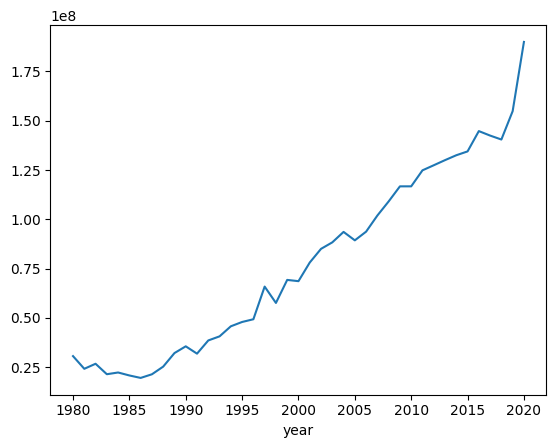

In [28]:
df.groupby("year")["gross"].mean().plot()